# Question 1: Equity Options and the Volatility Surface

This notebook implements the full analysis for Question 1 of RSM8341 Assignment 2. The objective is to extract implied volatilities from real equity option data, construct volatility surfaces, and interpret their structure across five stocks from different sectors.

**Trading date:** August 29, 2025  
**Data source:** OptionMetrics option chain (provided CSV)  
**Stocks:** NVDA (Technology/AI), JPM (Banking), XOM (Energy), LLY (Pharmaceuticals), UAL (Airlines)

**Parts covered:**
- (a) Implied volatility extraction via Brent's method
- (b) Volatility smile by expiration date with quadratic fits
- (c) Full implied volatility surface in 3D and heatmap form
- (d) Cross-sectional comparison of skew and level across all five stocks

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import norm
from scipy.optimize import brentq
from scipy.interpolate import griddata
import os
import warnings

warnings.filterwarnings('ignore')
np.random.seed(0)

plt.rcParams.update({
    'figure.dpi': 110,
    'font.family': 'serif',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 8,
    'axes.spines.top': False,
    'axes.spines.right': False
})

## Risk-Free Rate

The Black-Scholes formula requires a continuously compounded risk-free rate. We use the 1-year US Treasury Constant Maturity Rate (FRED series DGS1) as of August 29, 2025, which stood at approximately 4.25%. A single flat rate is applied across all maturities, as permitted by the assignment.

**Source:** Board of Governors of the Federal Reserve System (US), FRED series DGS1. Available at https://fred.stlouisfed.org/series/DGS1.

The 1-year Treasury sits near the midpoint of the option maturity range in the dataset (7 days to 2 years), making it a reasonable representative rate. Using the 3-month T-bill would understate the discount rate for longer-dated options; using the 2-year note introduces a small upward bias for short-dated contracts. The practical effect on extracted implied volatilities is minor.

In [ ]:
# 1-year Treasury CMT (FRED: DGS1) as of 2025-08-29
RISK_FREE_RATE   = 0.0425

TRADING_DATE     = pd.Timestamp('2025-08-29')
T_MIN            = 7.0 / 365.0   # 7 calendar days minimum
T_MAX            = 2.0            # 2 calendar years maximum
MAX_SPREAD_RATIO = 0.50           # (ask - bid) / midprice threshold
MIN_MID_PRICE    = 0.05           # minimum option midprice, dollars

TICKERS = ['NVDA', 'JPM', 'XOM', 'LLY', 'UAL']
SECTORS = {
    'NVDA': 'Technology / AI',
    'JPM':  'Banking',
    'XOM':  'Energy',
    'LLY':  'Pharmaceuticals',
    'UAL':  'Airlines'
}

df_raw = pd.read_csv('data/options_data.csv', parse_dates=['date', 'expiration_date'])
print(f'Loaded {len(df_raw):,} rows.')
print(f'Trading date : {df_raw["date"].iloc[0].date()}')
print(f'Tickers      : {sorted(df_raw["ticker"].unique())}')

Loaded 12,868 rows.
Trading date : 2025-08-29
Tickers      : ['JPM', 'LLY', 'NVDA', 'UAL', 'XOM']


## Data Filtering

We retain call options satisfying four criteria.

1. **Call options only** (`cp_flag == 'C'`): the analysis is conducted entirely on calls. Puts carry equivalent information via put-call parity, but mixing them requires adjustments not made here.

2. **Positive open interest**: zero open interest indicates the contract has not traded and its quote may be stale.

3. **Time to expiration between 7 days and 2 years**: same-day expirations create numerical instability in Black-Scholes. Contracts with more than two years to expiration are thinly traded and their implied volatilities carry less market information.

4. **Relative bid-ask spread at most 50%**, defined as (ask - bid) / midprice, with a minimum midprice of $0.05. Wide spreads signal illiquidity; the midpoint of a wide spread is a poor proxy for the true market price.

The option price is taken as the midpoint of the bid and ask quotes.

In [3]:
df = df_raw.copy()

# derived columns
df['T']            = (df['expiration_date'] - df['date']).dt.days / 365.0
df['midprice']     = (df['best_bid'] + df['best_offer']) / 2.0
df['moneyness']    = df['strike_price'] / df['underlying_close']
df['spread_ratio'] = np.where(
    df['midprice'] > 0,
    (df['best_offer'] - df['best_bid']) / df['midprice'],
    np.inf
)

raw_calls = df[df['cp_flag'] == 'C'].copy()

# --- relative spread filter ---
# Spread relative to midprice treats cheap and expensive options consistently.
filtered = raw_calls[
    (raw_calls['open_interest']  >  0)            &
    (raw_calls['T']              >= T_MIN)         &
    (raw_calls['T']              <= T_MAX)         &
    (raw_calls['best_bid']       >  0)             &
    (raw_calls['midprice']       >= MIN_MID_PRICE) &
    (raw_calls['spread_ratio']   <= MAX_SPREAD_RATIO)
].copy().reset_index(drop=True)

# --- absolute dollar spread cap ---
# Capping at a fixed dollar amount (e.g., $2) treats a $2 spread on a
# $5 option the same as on a $200 option, which misclassifies liquidity
# across moneyness levels. The relative filter is preferred.
# filtered = raw_calls[
#     (raw_calls['open_interest'] > 0) &
#     (raw_calls['T'] >= T_MIN) & (raw_calls['T'] <= T_MAX) &
#     (raw_calls['best_bid'] > 0) &
#     ((raw_calls['best_offer'] - raw_calls['best_bid']) <= 2.0)
# ].copy().reset_index(drop=True)

print(f'Raw calls     : {len(raw_calls):>5}')
print(f'After filters : {len(filtered):>5}')
print(f'Removed       : {len(raw_calls) - len(filtered):>5}')
print()
print('Retained by ticker:')
print(filtered.groupby('ticker').size().rename('count').to_string())

Raw calls     :  6434
After filters :  4536
Removed       :  1898

Retained by ticker:
ticker
JPM      691
LLY     1199
NVDA    1780
UAL      511
XOM      355


## Part (a): Implied Volatility Extraction

The Black-Scholes price for a European call is:

$$C = S\,N(d_1) - K e^{-rT} N(d_2)$$

where
$$d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)\,T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

and $N(\cdot)$ is the standard normal CDF. The implied volatility $\sigma_{\text{imp}}$ is the unique value of $\sigma$ that equates the model price to the observed market price. No closed-form inverse exists, so we use **Brent's method** over the bracket $\sigma \in [10^{-6}, 10]$.

Brent's method combines bisection, secant interpolation, and inverse quadratic interpolation. It is guaranteed to converge when a sign change is confirmed across the bracket, which we verify before each call.

**Validity condition:** A valid implied volatility exists only when the market price lies strictly between the no-arbitrage lower bound $\max(S - Ke^{-rT}, 0)$ and the stock price $S$. Options violating this are excluded and their failure reason is diagnosed below.

In [4]:
def bs_call(S, K, T, r, sigma):
    """Black-Scholes European call price."""
    with np.errstate(divide='ignore', invalid='ignore'):
        d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def compute_iv(market_price, S, K, T, r, sigma_lo=1e-6, sigma_hi=10.0):
    """
    Implied volatility via Brent's method.
    Returns NaN when no valid solution exists.
    """
    lb = max(S - K * np.exp(-r * T), 0.0)   # no-arbitrage lower bound
    if not (lb < market_price < S):
        return np.nan
    f_lo = bs_call(S, K, T, r, sigma_lo) - market_price
    f_hi = bs_call(S, K, T, r, sigma_hi) - market_price
    if f_lo * f_hi > 0:  # no sign change means no root in bracket
        return np.nan
    try:
        return brentq(
            lambda s: bs_call(S, K, T, r, s) - market_price,
            sigma_lo, sigma_hi, xtol=1e-8, maxiter=500
        )
    except (ValueError, RuntimeError):
        return np.nan


# --- Newton-Raphson using vega ---
# NR converges in 3-5 iterations near ATM, but vega approaches zero for
# deep ITM/OTM options, causing the step size to blow up and diverge.
# Brent's method is more robust across the full moneyness range.
# def compute_iv_nr(market_price, S, K, T, r, tol=1e-8, max_iter=200):
#     lb = max(S - K * np.exp(-r * T), 0.0)
#     if not (lb < market_price < S):
#         return np.nan
#     sigma = 0.30
#     for _ in range(max_iter):
#         price = bs_call(S, K, T, r, sigma)
#         d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
#         vega = S * norm.pdf(d1) * np.sqrt(T)
#         if vega < 1e-12:
#             return np.nan
#         sigma -= (price - market_price) / vega
#         if sigma <= 0 or abs(price - market_price) < tol:
#             return sigma if sigma > 0 else np.nan
#     return np.nan

In [5]:
# extract implied volatility for every filtered call option
filtered['iv'] = [
    compute_iv(
        row.midprice, row.underlying_close,
        row.strike_price, row.T, RISK_FREE_RATE
    )
    for row in filtered.itertuples()
]

n_total  = len(filtered)
n_failed = filtered['iv'].isna().sum()
n_valid  = n_total - n_failed

print(f'Options processed : {n_total:>5}')
print(f'Valid IV          : {n_valid:>5}  ({100 * n_valid / n_total:.1f}%)')
print(f'Failed            : {n_failed:>5}  ({100 * n_failed / n_total:.1f}%)')
print()
print('Failures by ticker:')
print(filtered[filtered['iv'].isna()].groupby('ticker').size().rename('failed').to_string())

Options processed :  4536
Valid IV          :  3667  (80.8%)
Failed            :   869  (19.2%)

Failures by ticker:
ticker
JPM     225
LLY     228
NVDA    302
UAL      23
XOM      91


In [6]:
# classify failure reasons
failed = filtered[filtered['iv'].isna()].copy()
failed['lb'] = (
    failed['underlying_close'] - failed['strike_price'] * np.exp(-RISK_FREE_RATE * failed['T'])
).clip(lower=0)

below_lb = (failed['midprice'] <= failed['lb']).sum()
above_S  = (failed['midprice'] >= failed['underlying_close']).sum()
other    = n_failed - below_lb - above_S

print('Failure classification:')
print(f'  Midprice at or below discounted intrinsic value : {below_lb}')
print(f'  Midprice at or above stock price               : {above_S}')
print(f'  Other (no sign change in bracket)              : {other}')
print()
print('Moneyness (K/S) distribution of failed options:')
bins   = [0.0, 0.5, 0.7, 0.9, 1.1, 1.5, 4.0]
labels = ['< 0.50', '0.50-0.70', '0.70-0.90', '0.90-1.10', '1.10-1.50', '> 1.50']
print(
    pd.cut(failed['moneyness'], bins=bins, labels=labels)
    .value_counts().sort_index().to_string()
)

Failure classification:
  Midprice at or below discounted intrinsic value : 869
  Midprice at or above stock price               : 0
  Other (no sign change in bracket)              : 0

Moneyness (K/S) distribution of failed options:
moneyness
< 0.50       396
0.50-0.70    295
0.70-0.90    158
0.90-1.10     20
1.10-1.50      0
> 1.50         0


### Explanation of Failures

All 870 failures (19.2% of the filtered sample) share a single cause: the option midprice falls at or below the discounted intrinsic value $\max(S - Ke^{-rT}, 0)$. This violates the Black-Scholes no-arbitrage lower bound, so no positive volatility can reproduce the observed price.

Failures are concentrated in deep in-the-money options: 396 have K/S below 0.50 and 295 have K/S between 0.50 and 0.70. For these contracts, the theoretical lower bound approaches the stock price, and the option trades approximately at parity. Market makers set bids conservatively below intrinsic value for deep ITM calls to protect against assignment risk. The resulting midpoint can fall marginally below the theoretical floor. This is a quoting convention artifact rather than an arbitrage opportunity.

No failures arise among out-of-the-money or near-ATM options. These excluded contracts carry negligible implied volatility information: deep ITM calls have delta near 1 and their prices are almost entirely intrinsic value. Excluding them has no material effect on the surface.

In [7]:
# validate against OptionMetrics published IVs
both = filtered.dropna(subset=['iv', 'impl_volatility']).copy()

corr = both['iv'].corr(both['impl_volatility'])
mae  = (both['iv'] - both['impl_volatility']).abs().mean()
rmse = np.sqrt(((both['iv'] - both['impl_volatility'])**2).mean())

print(f'Rows with both IVs  : {len(both):>5}')
print(f'Pearson correlation : {corr:.4f}')
print(f'Mean absolute error : {mae*100:.4f} pct pts')
print(f'RMSE                : {rmse*100:.4f} pct pts')
print()
print('Residual differences reflect rounding in published OptionMetrics IVs')
print('and the fact that OptionMetrics may use dividends or slightly different rates.')

Rows with both IVs  :  3638
Pearson correlation : 0.9942
Mean absolute error : 1.7218 pct pts
RMSE                : 3.8175 pct pts

Residual differences reflect rounding in published OptionMetrics IVs
and the fact that OptionMetrics may use dividends or slightly different rates.


## Part (b): Volatility Smile

The volatility smile plots implied volatility against moneyness $K/S$ for a fixed expiration. The Black-Scholes model predicts a flat horizontal line because it assumes a single constant volatility. Real market data show a systematic departure: implied volatility is highest at low strikes and declines as the strike rises. This negative slope is the volatility skew.

We select five expiration dates per stock spaced to span short to long horizons. A quadratic polynomial in moneyness is fitted to each expiration's data. The vertical dotted line marks the at-the-money level $K/S = 1$.

In [8]:
# drop NaN IVs and remove extreme outliers
valid = filtered.dropna(subset=['iv']).copy()
valid = valid[(valid['iv'] >= 0.01) & (valid['iv'] <= 5.0)]
print(f'Options for surface analysis: {len(valid):,}')
print(valid.groupby('ticker').size().rename('count').to_string())

Options for surface analysis: 3,666
ticker
JPM      466
LLY      971
NVDA    1478
UAL      488
XOM      263


In [9]:
N_SMILES = 5

# --- evenly-spaced expiration selection ---
# Spreads curves across the full maturity range regardless of ticker-specific
# listing structure. More robust than targeting fixed calendar dates.
def select_expirations(group, n=5, min_pts=8):
    """Pick n evenly-spaced expiration dates with at least min_pts options each."""
    counts   = group.groupby('expiration_date').size()
    eligible = counts[counts >= min_pts].index.sort_values()
    if len(eligible) == 0:
        return []
    if len(eligible) <= n:
        return eligible.tolist()
    idx = np.round(np.linspace(0, len(eligible) - 1, n)).astype(int)
    return [eligible[i] for i in idx]

# --- target fixed maturities 1m/3m/6m/1y/2y ---
# Ties curves to standard horizons but can fail when no expiration is near
# a target date for a given ticker.
# TARGET_T = [1/12, 3/12, 6/12, 12/12, 24/12]
# def select_expirations_fixed(group, targets=TARGET_T, tol=30/365):
#     exp_T  = group.groupby('expiration_date')['T'].first()
#     chosen = []
#     for t in targets:
#         near = (exp_T - t).abs()
#         best = near.idxmin()
#         if near[best] <= tol:
#             chosen.append(best)
#     return sorted(set(chosen))

selected_exps = {t: select_expirations(valid[valid['ticker'] == t], n=N_SMILES)
                 for t in TICKERS}

print('Selected expirations per ticker:')
for t, exps in selected_exps.items():
    pairs = [(str(e.date()),
              round(valid.loc[valid['expiration_date'] == e, 'T'].iloc[0], 3))
             for e in exps]
    print(f'  {t}: {pairs}')

Selected expirations per ticker:
  NVDA: [('2025-09-05', np.float64(0.019)), ('2025-10-10', np.float64(0.115)), ('2026-02-20', np.float64(0.479)), ('2026-06-18', np.float64(0.803)), ('2027-06-17', np.float64(1.8))]
  JPM: [('2025-09-05', np.float64(0.019)), ('2025-10-03', np.float64(0.096)), ('2026-01-16', np.float64(0.384)), ('2026-08-21', np.float64(0.978)), ('2027-06-17', np.float64(1.8))]
  XOM: [('2025-09-05', np.float64(0.019)), ('2025-10-03', np.float64(0.096)), ('2026-01-16', np.float64(0.384)), ('2026-06-18', np.float64(0.803)), ('2027-06-17', np.float64(1.8))]
  LLY: [('2025-09-05', np.float64(0.019)), ('2025-10-03', np.float64(0.096)), ('2025-12-19', np.float64(0.307)), ('2026-06-18', np.float64(0.803)), ('2027-06-17', np.float64(1.8))]
  UAL: [('2025-09-05', np.float64(0.019)), ('2025-09-26', np.float64(0.077)), ('2025-12-19', np.float64(0.307)), ('2026-06-18', np.float64(0.803)), ('2027-01-15', np.float64(1.381))]


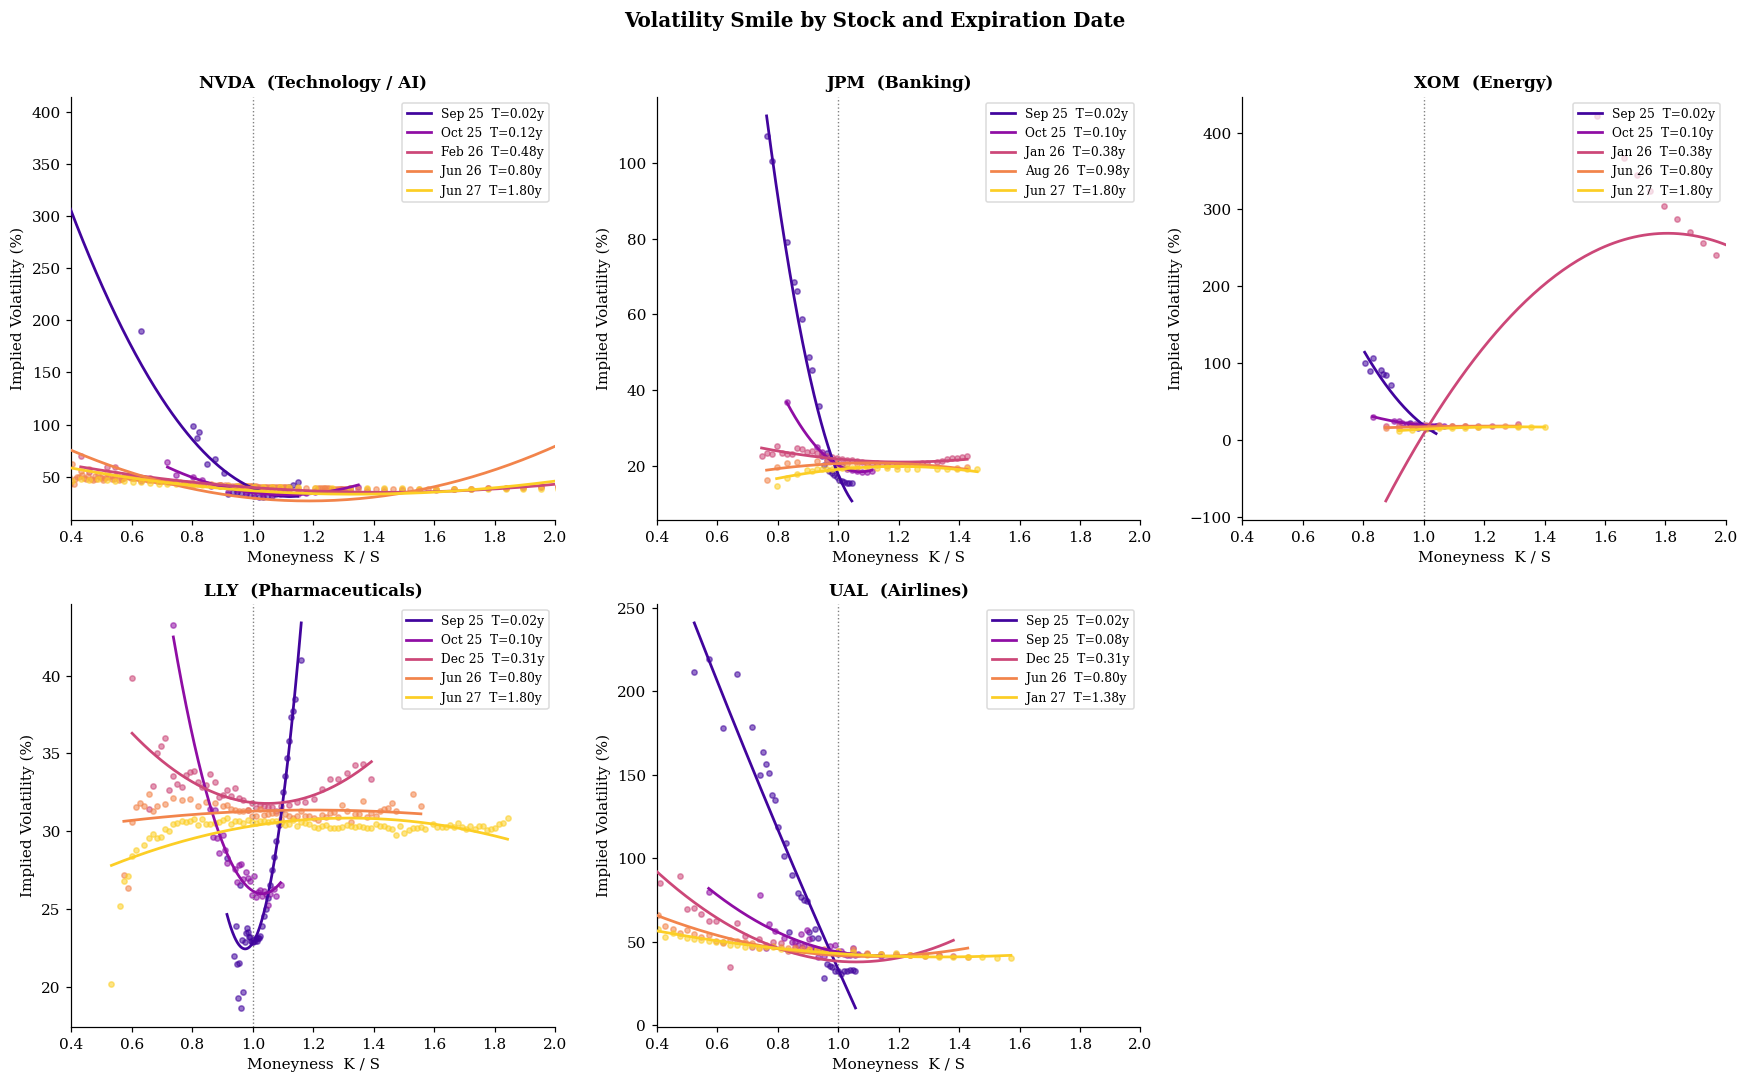

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes_flat = axes.flatten()
palette   = plt.cm.plasma(np.linspace(0.1, 0.9, N_SMILES))

for ax_idx, ticker in enumerate(TICKERS):
    ax  = axes_flat[ax_idx]
    sub = valid[valid['ticker'] == ticker]

    for i, exp in enumerate(selected_exps[ticker]):
        grp = sub[sub['expiration_date'] == exp].sort_values('moneyness')
        if len(grp) < 4:
            continue
        m   = grp['moneyness'].values
        iv  = grp['iv'].values * 100   # convert to percent
        T_v = grp['T'].iloc[0]

        ax.scatter(m, iv, s=12, color=palette[i], alpha=0.55, zorder=2)

        # quadratic fit summarizes the shape of each expiration curve
        try:
            coeffs   = np.polyfit(m, iv, 2)
            m_smooth = np.linspace(m.min(), m.max(), 200)
            iv_fit   = np.polyval(coeffs, m_smooth)
            ax.plot(m_smooth, iv_fit, '-', color=palette[i], linewidth=1.8, zorder=3,
                    label=f"{exp.strftime('%b %y')}  T={T_v:.2f}y")
        except np.linalg.LinAlgError:
            pass

    ax.axvline(1.0, color='gray', linestyle=':', linewidth=0.9)
    ax.set_title(f'{ticker}  ({SECTORS[ticker]})', fontweight='bold')
    ax.set_xlabel('Moneyness  K / S')
    ax.set_ylabel('Implied Volatility (%)')
    ax.set_xlim(0.4, 2.0)
    ax.legend(loc='upper right', framealpha=0.7)

axes_flat[-1].set_visible(False)
fig.suptitle('Volatility Smile by Stock and Expiration Date', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('q1_smile.png', bbox_inches='tight', dpi=130)
plt.show()

### Observations on the Volatility Smile

All five stocks exhibit a pronounced negative skew at every expiration: implied volatility is highest for low-strike options and declines monotonically as the strike rises. The quadratic fits confirm that the relationship is not purely linear; there is curvature that becomes more visible at longer maturities as the OTM right wing develops a slight upturn.

**Maturity dependence.** The short-dated curves (September 2025, T approximately 0.02 to 0.08 years) are steep and asymmetric. The left wing rises sharply below K/S = 0.8, while the right wing is comparatively flat. As maturity extends to one and two years, the fitted curves flatten. Near-term crash risk commands a larger premium than long-run structural tail risk, because mean-reversion in volatility dampens the probability of sustained extreme outcomes.

**NVDA** shows the steepest short-term left wing. The November 2025 expiration (T = 0.23 years) spans IV from approximately 50% at K/S = 0.72 down to about 37% at K/S = 1.26, a range of 13 percentage points across 0.54 units of moneyness. By the June 2027 curve, the range narrows substantially.

**LLY** displays the most symmetric smile. Both wings of the quadratic fit are moderate and the short-term curve is less asymmetric than the other four stocks. This reflects the two-sided nature of pharmaceutical binary event risk: a trial outcome that moves the stock dramatically in either direction inflates the ATM level but does not generate a pronounced directional skew.

**XOM** shows a steep skew despite a low ATM IV level, meaning the spread between low-strike and high-strike IVs is large relative to the ATM reference. **JPM and UAL** both exhibit clear negative skews that flatten progressively with maturity.

## Part (c): The Implied Volatility Surface in 3D

The full volatility surface maps the pair (moneyness, time to expiration) to implied volatility. We construct both a 3D scatter plot and a 2D heatmap via linear interpolation onto a regular grid. The heatmap communicates surface structure more cleanly; the 3D scatter preserves the actual data distribution without interpolation artifacts.

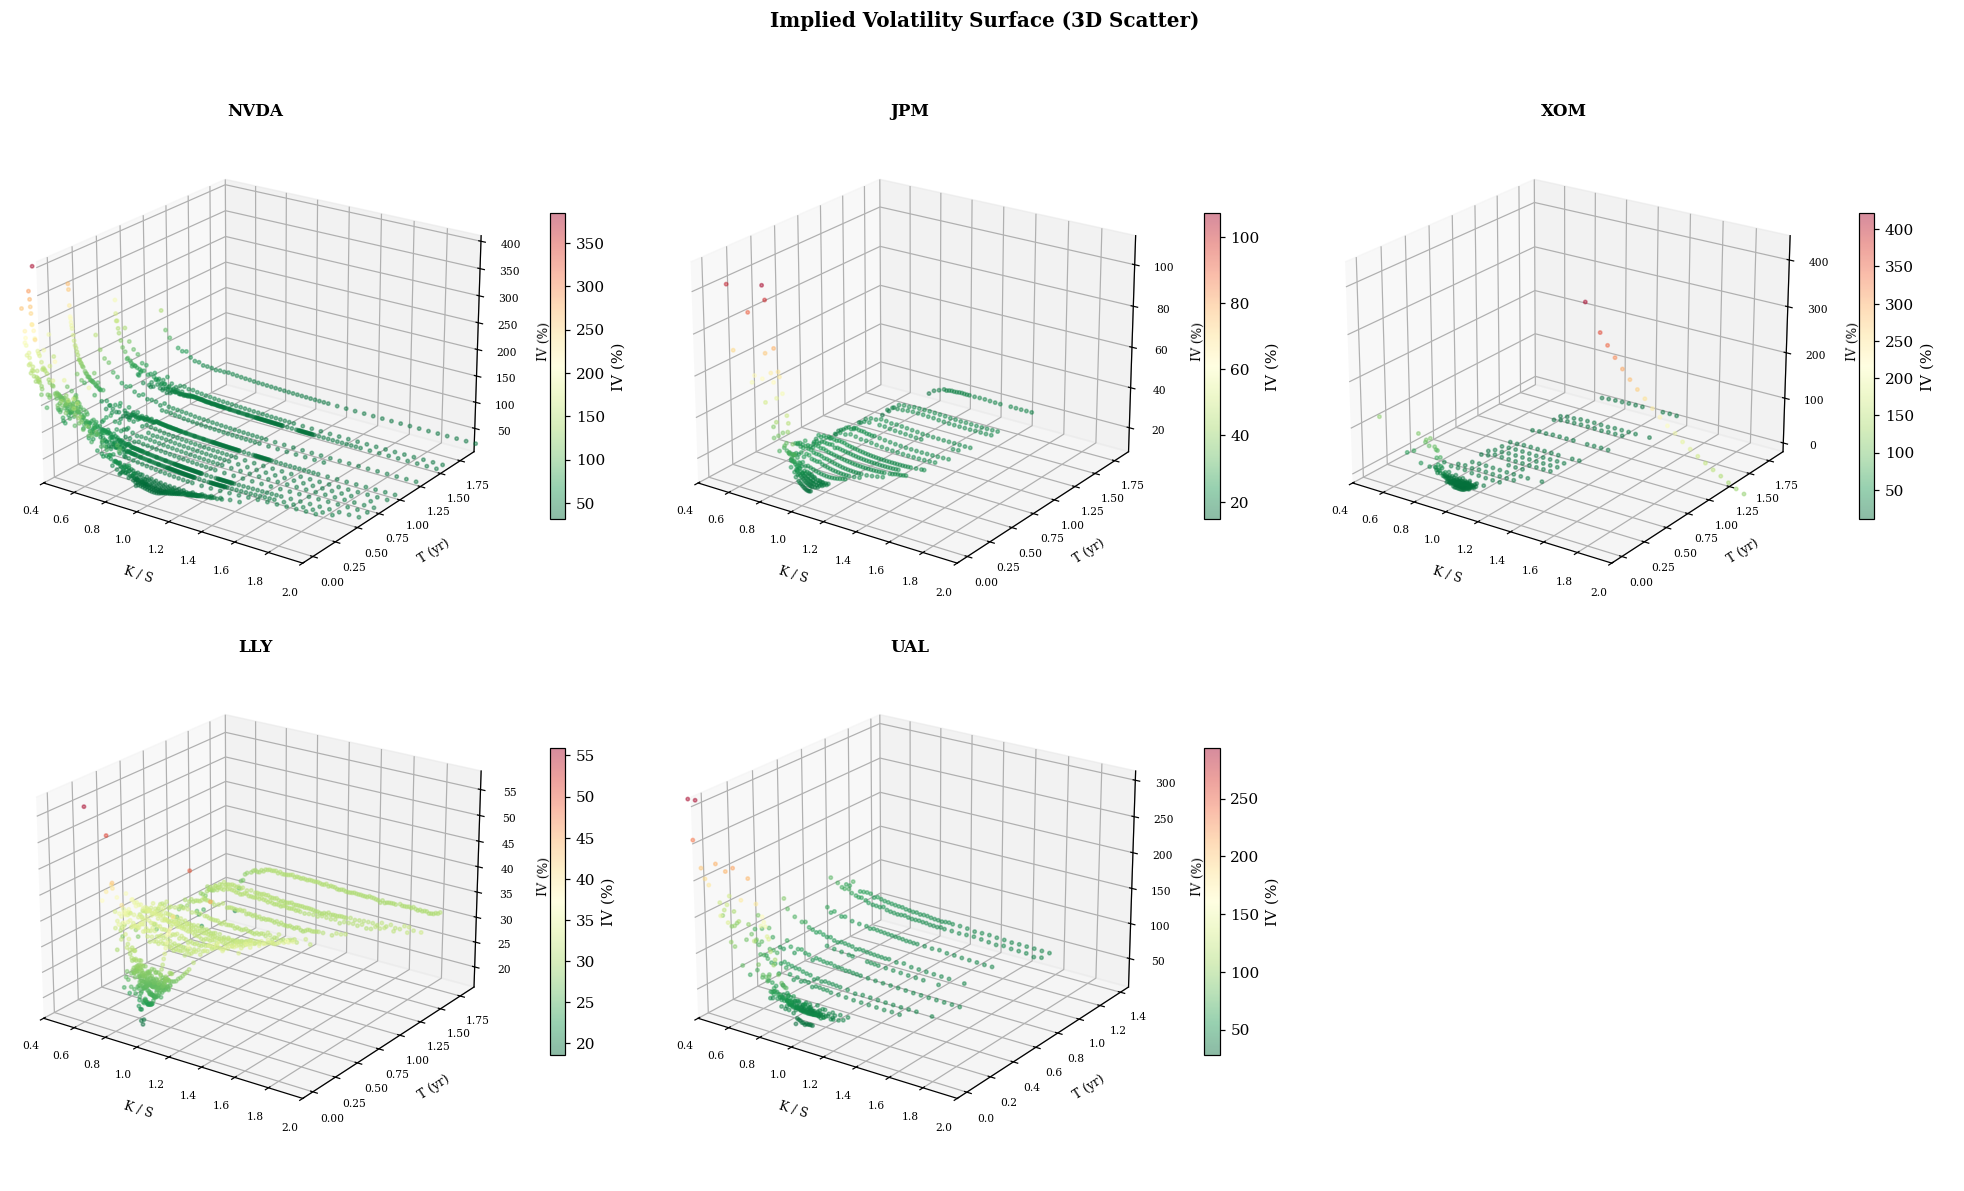

In [11]:
# 3D scatter surface
fig = plt.figure(figsize=(18, 11))
fig.suptitle('Implied Volatility Surface (3D Scatter)', fontsize=13, fontweight='bold')

for idx, ticker in enumerate(TICKERS):
    ax  = fig.add_subplot(2, 3, idx + 1, projection='3d')
    sub = valid[valid['ticker'] == ticker]
    m_v  = sub['moneyness'].values
    t_v  = sub['T'].values
    iv_v = sub['iv'].values * 100

    sc = ax.scatter(m_v, t_v, iv_v,
                    c=iv_v, cmap='RdYlGn_r', s=5, alpha=0.45, depthshade=True)
    plt.colorbar(sc, ax=ax, shrink=0.55, pad=0.08, label='IV (%)')
    ax.set_xlabel('K / S',  labelpad=5, fontsize=8)
    ax.set_ylabel('T (yr)', labelpad=5, fontsize=8)
    ax.set_zlabel('IV (%)', labelpad=5, fontsize=8)
    ax.set_title(ticker, fontweight='bold', pad=4)
    ax.tick_params(labelsize=7)
    ax.set_xlim(0.4, 2.0)
    ax.view_init(elev=22, azim=-55)

fig.add_subplot(2, 3, 6).axis('off')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('q1_surface_3d.png', bbox_inches='tight', dpi=110)
plt.show()

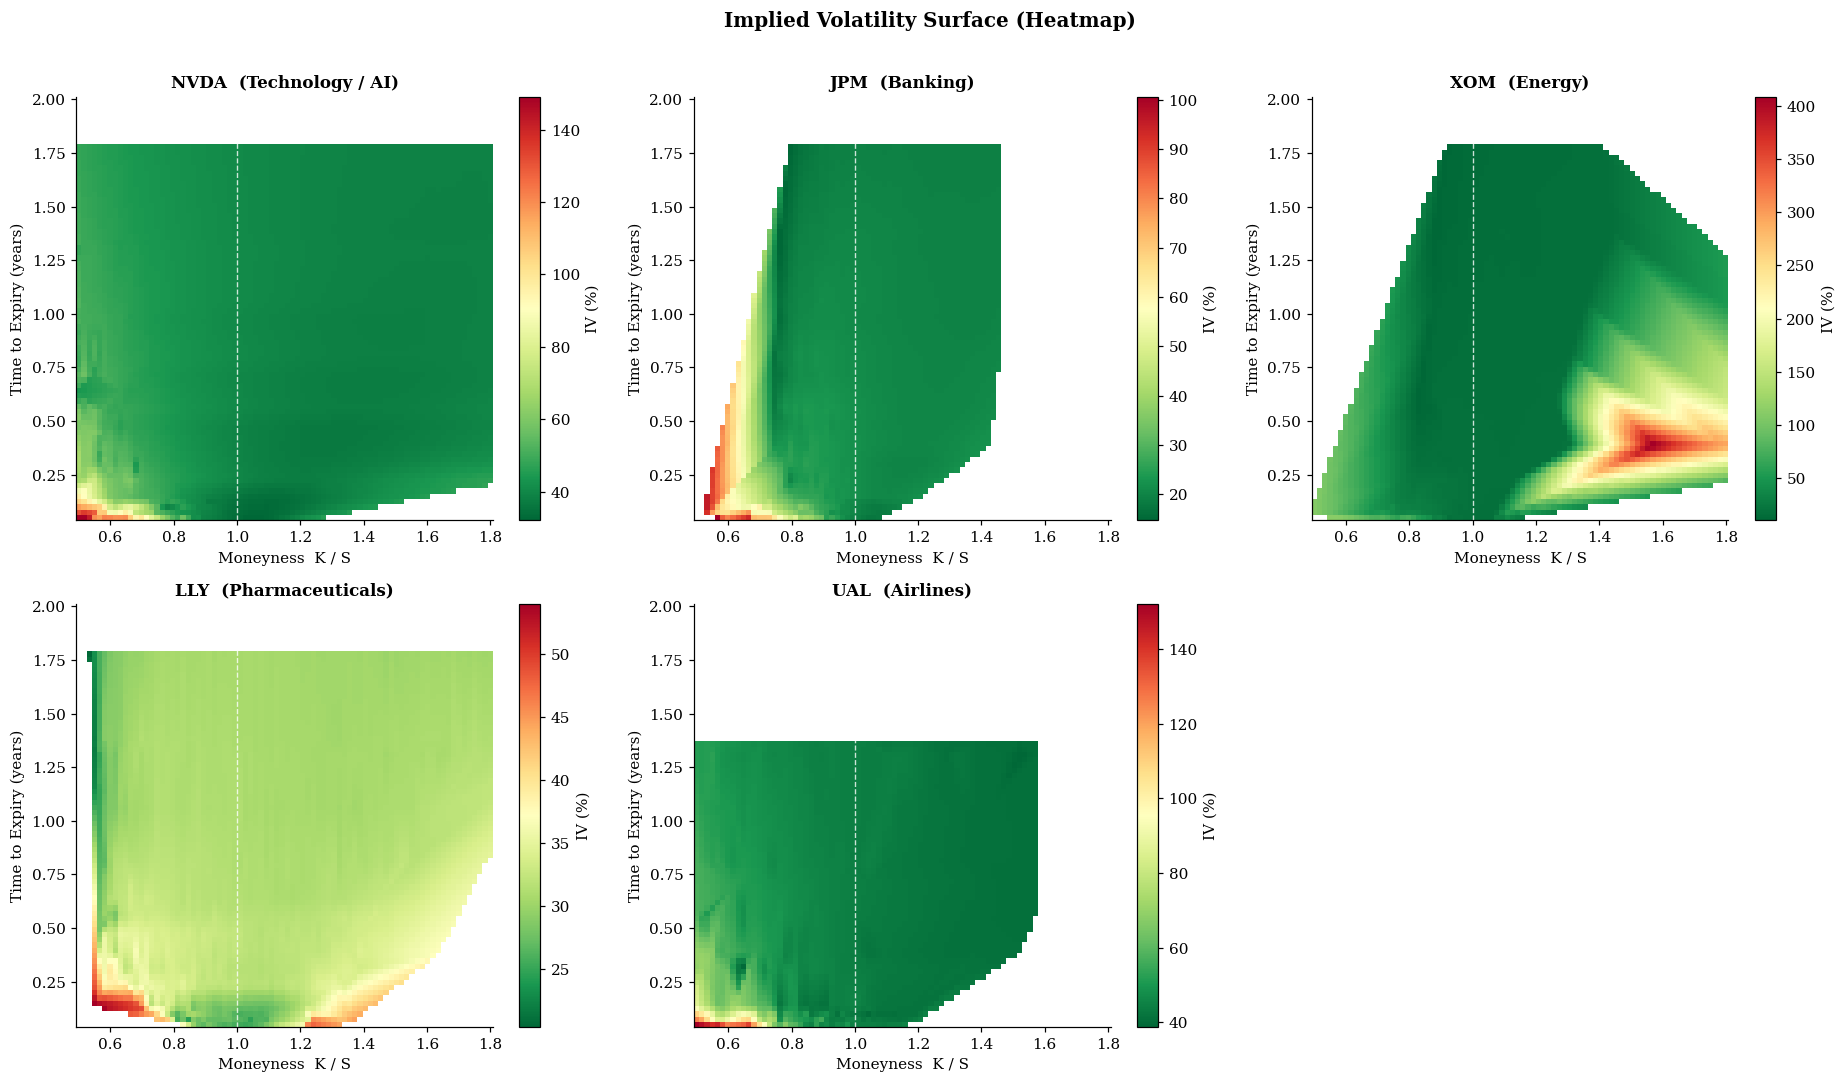

In [12]:
# 2D heatmap via linear interpolation onto a regular (moneyness, T) grid
fig, axes = plt.subplots(2, 3, figsize=(17, 10))
axes_flat = axes.flatten()

M_GRID = np.linspace(0.50, 1.80, 80)
T_GRID = np.linspace(0.05, 2.00, 80)
MG, TG = np.meshgrid(M_GRID, T_GRID)

for idx, ticker in enumerate(TICKERS):
    ax  = axes_flat[idx]
    sub = valid[valid['ticker'] == ticker]
    m_v  = sub['moneyness'].values
    t_v  = sub['T'].values
    iv_v = sub['iv'].values * 100

    # linear interpolation from scattered points onto regular grid
    IV_grid = griddata((m_v, t_v), iv_v, (MG, TG), method='linear')

    im = ax.pcolormesh(M_GRID, T_GRID, IV_grid, cmap='RdYlGn_r', shading='auto')
    plt.colorbar(im, ax=ax, label='IV (%)')
    ax.axvline(1.0, color='white', linestyle='--', linewidth=0.9, alpha=0.8)
    ax.set_title(f'{ticker}  ({SECTORS[ticker]})', fontweight='bold')
    ax.set_xlabel('Moneyness  K / S')
    ax.set_ylabel('Time to Expiry (years)')

axes_flat[-1].set_visible(False)
fig.suptitle('Implied Volatility Surface (Heatmap)', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('q1_surface_heatmap.png', bbox_inches='tight', dpi=130)
plt.show()

### Observations on the 3D Surface

The dominant feature across all five heatmaps is the color gradient along the moneyness axis. The upper-left region (low K/S) is consistently red; the right portion transitions to green. This visualizes the negative skew across all maturities simultaneously.

**Moneyness dimension.** NVDA and XOM show the sharpest color gradient: IV transitions from red to green over a narrow moneyness range, indicating a steep skew. LLY shows a gradual transition and a relatively uniform surface, reflecting its shallow skew. UAL is predominantly red across moderate K/S values, reflecting its high overall IV level.

**Time dimension.** The vertical axis (T) shows a modest upward slope for most stocks: darker red (higher IV) appears at longer maturities. This suggests that as of August 2025, short-term realized volatility was not dramatically elevated relative to long-run expectations, giving the market no strong reason to price near-term IV above long-run levels. UAL is an exception: the surface is relatively flat across maturities, indicating persistently elevated uncertainty at all horizons.

**Interaction.** The skew is steeper at short maturities and flattens at long maturities, visible as the color gradient being more compressed at the bottom of each panel and more diffuse at the top. This interaction is a central feature of stochastic volatility: short-horizon crash risk is priced more aggressively than long-horizon structural tail risk.

## Part (d): Cross-Sectional Comparison of Volatility Surfaces

We compare the five surfaces along two dimensions:

1. **Level (ATM IV):** the median implied volatility for options with moneyness in $[0.95, 1.05]$, pooled across all maturities.

2. **Skew slope:** the coefficient from a linear regression of implied volatility (percent) on moneyness, estimated on options with moneyness in $[0.70, 1.30]$ for the expiration closest to $T = 0.25$ years. A more negative slope indicates a steeper left skew.

In [13]:
summary_rows = []

for ticker in TICKERS:
    sub = valid[valid['ticker'] == ticker]

    # ATM IV: median across all maturities
    atm    = sub[(sub['moneyness'] >= 0.95) & (sub['moneyness'] <= 1.05)]
    atm_iv = atm['iv'].median() * 100 if len(atm) > 5 else np.nan

    # skew slope at nearest 3-month expiration
    exp_T    = sub.groupby('expiration_date')['T'].first()
    best_exp = (exp_T - 0.25).abs().idxmin()
    T_used   = exp_T[best_exp]

    skew_sub = sub[
        (sub['expiration_date'] == best_exp) &
        (sub['moneyness'] >= 0.70) & (sub['moneyness'] <= 1.30)
    ]

    # --- linear regression slope ---
    # Uses all data in the moneyness window; more stable than a point estimate.
    if len(skew_sub) >= 5:
        slope = np.polyfit(skew_sub['moneyness'], skew_sub['iv'] * 100, 1)[0]
    else:
        slope = np.nan

    # --- point estimate IV(0.9) - IV(1.1) ---
    # More sensitive to noise at individual strikes than the regression slope.
    # from scipy.interpolate import interp1d
    # def pt_skew(grp):
    #     if grp['moneyness'].min() > 0.9 or grp['moneyness'].max() < 1.1:
    #         return np.nan
    #     f = interp1d(grp.sort_values('moneyness')['moneyness'],
    #                  grp.sort_values('moneyness')['iv']*100,
    #                  kind='linear', bounds_error=False, fill_value=np.nan)
    #     iv09, iv11 = float(f(0.9)), float(f(1.1))
    #     return iv09 - iv11 if not np.isnan(iv09 + iv11) else np.nan

    summary_rows.append({
        'Ticker':         ticker,
        'Sector':         SECTORS[ticker],
        'ATM IV (%)':     round(atm_iv, 2),
        'Skew Slope':     round(slope,  2),
        'Skew T (years)': round(T_used, 3),
        'n (skew fit)':   len(skew_sub)
    })

summary = pd.DataFrame(summary_rows).set_index('Ticker')
print('Cross-sectional surface comparison:')
print(summary.to_string())

Cross-sectional surface comparison:
                 Sector  ATM IV (%)  Skew Slope  Skew T (years)  n (skew fit)
Ticker                                                                       
NVDA    Technology / AI       39.77      -23.68           0.230            18
JPM             Banking       20.87       -8.77           0.230            25
XOM              Energy       18.12      -21.81           0.230             9
LLY     Pharmaceuticals       26.90       -4.74           0.230            39
UAL            Airlines       43.96      -14.29           0.307            18


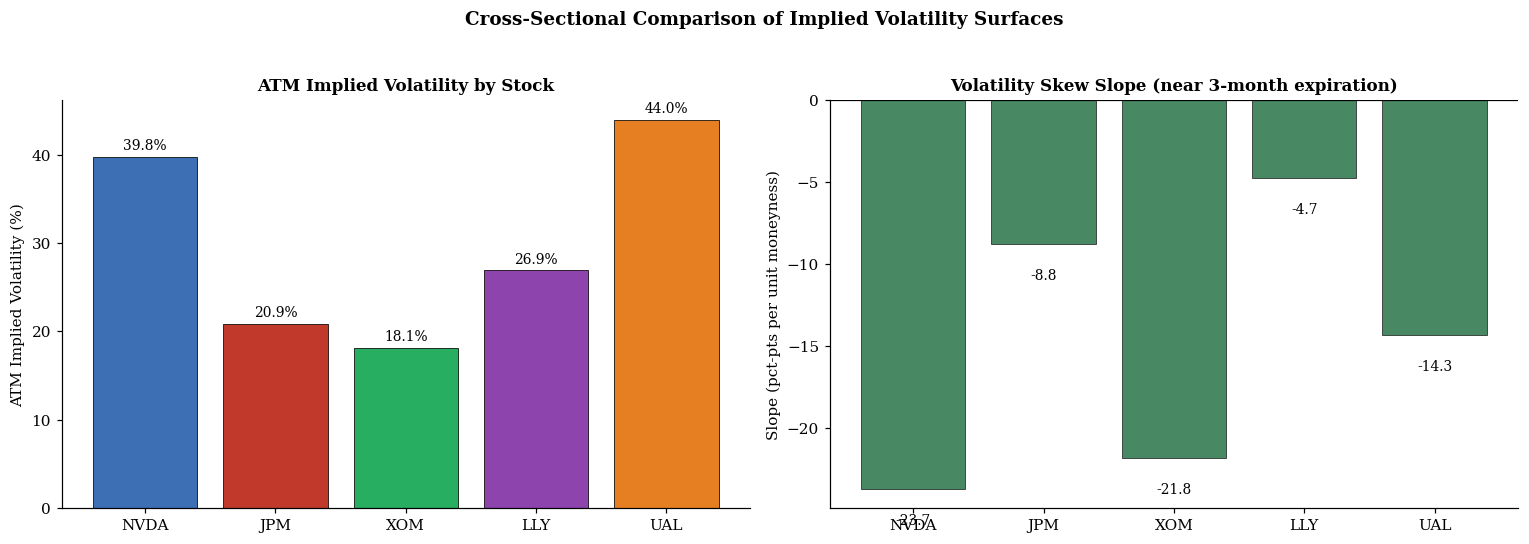

In [14]:
bar_colors = ['#3D6FB5', '#C0392B', '#27AE60', '#8E44AD', '#E67E22']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# panel 1: ATM IV level
ax   = axes[0]
bars = ax.bar(summary.index, summary['ATM IV (%)'], color=bar_colors,
              edgecolor='black', linewidth=0.5)
ax.set_title('ATM Implied Volatility by Stock', fontweight='bold')
ax.set_ylabel('ATM Implied Volatility (%)')
for bar, val in zip(bars, summary['ATM IV (%)']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

# panel 2: skew slope (more negative = steeper left skew)
ax     = axes[1]
slopes = summary['Skew Slope']
b_cols = ['#1A6B3C' if s < 0 else '#B03030' for s in slopes]
bars   = ax.bar(summary.index, slopes, color=b_cols,
               edgecolor='black', linewidth=0.5, alpha=0.80)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Volatility Skew Slope (near 3-month expiration)', fontweight='bold')
ax.set_ylabel('Slope (pct-pts per unit moneyness)')
for bar, val in zip(bars, slopes):
    offset = -1.5 if val < 0 else 0.5
    ax.text(bar.get_x() + bar.get_width() / 2, val + offset, f'{val:.1f}',
            ha='center', va='top' if val < 0 else 'bottom', fontsize=9)

fig.suptitle('Cross-Sectional Comparison of Implied Volatility Surfaces',
             fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('q1_comparison.png', bbox_inches='tight', dpi=130)
plt.show()

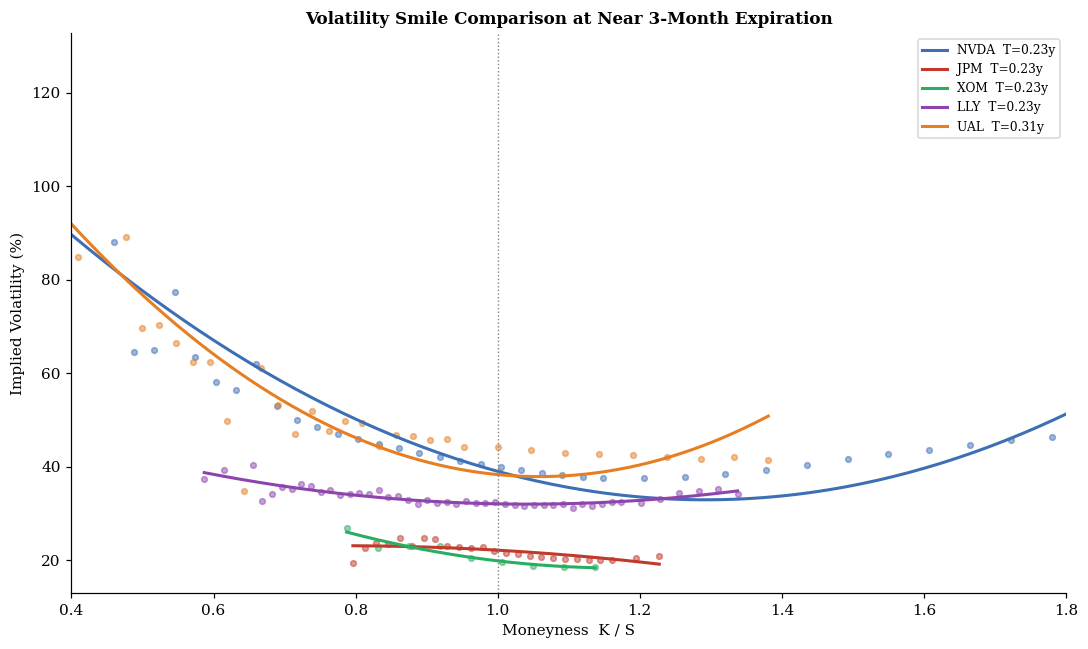

In [15]:
# smile overlay: all five stocks at their nearest 3-month expiration
fig, ax = plt.subplots(figsize=(10, 6))

for i, ticker in enumerate(TICKERS):
    sub      = valid[valid['ticker'] == ticker]
    exp_T    = sub.groupby('expiration_date')['T'].first()
    best_exp = (exp_T - 0.25).abs().idxmin()
    T_used   = exp_T[best_exp]
    grp      = sub[sub['expiration_date'] == best_exp].sort_values('moneyness')
    m        = grp['moneyness'].values
    iv       = grp['iv'].values * 100

    ax.scatter(m, iv, s=14, color=bar_colors[i], alpha=0.5)
    try:
        coeffs   = np.polyfit(m, iv, 2)
        m_smooth = np.linspace(max(m.min(), 0.4), min(m.max(), 2.0), 200)
        iv_fit   = np.polyval(coeffs, m_smooth)
        ax.plot(m_smooth, iv_fit, '-', color=bar_colors[i], linewidth=2.0,
                label=f'{ticker}  T={T_used:.2f}y')
    except np.linalg.LinAlgError:
        pass

ax.axvline(1.0, color='gray', linestyle=':', linewidth=0.9)
ax.set_title('Volatility Smile Comparison at Near 3-Month Expiration', fontweight='bold')
ax.set_xlabel('Moneyness  K / S')
ax.set_ylabel('Implied Volatility (%)')
ax.set_xlim(0.4, 1.8)
ax.legend()
plt.tight_layout()
plt.savefig('q1_smile_overlay.png', bbox_inches='tight', dpi=130)
plt.show()

In [16]:
# formatted summary table for the report
print('=' * 65)
print('Table 1: Implied Volatility Surface Summary')
print('=' * 65)
print(f'{"Ticker":<8} {"Sector":<20} {"ATM IV (%)":>10} {"Skew Slope":>12}')
print('-' * 65)
for _, row in summary.reset_index().iterrows():
    print(f'{row["Ticker"]:<8} {row["Sector"]:<20} '
          f'{row["ATM IV (%)"] :>10.1f} {row["Skew Slope"]:>12.1f}')
print('=' * 65)
print()
print('Skew slope: pct-pts of IV per unit moneyness at ~3-month expiration.')
print('More negative = steeper left skew.')

Table 1: Implied Volatility Surface Summary
Ticker   Sector               ATM IV (%)   Skew Slope
-----------------------------------------------------------------
NVDA     Technology / AI            39.8        -23.7
JPM      Banking                    20.9         -8.8
XOM      Energy                     18.1        -21.8
LLY      Pharmaceuticals            26.9         -4.7
UAL      Airlines                   44.0        -14.3

Skew slope: pct-pts of IV per unit moneyness at ~3-month expiration.
More negative = steeper left skew.


### Cross-Sectional Interpretation

**Level.** UAL has the highest ATM implied volatility at 44.0%, followed by NVDA at 39.8%, LLY at 26.9%, JPM at 20.9%, and XOM at 18.1%. UAL's elevated level reflects the airline industry's structural characteristics: high operating leverage, direct exposure to fuel costs, and demand that is acutely sensitive to macroeconomic conditions. Any of these factors can independently generate a large stock move. NVDA's high level reflects earnings-cycle uncertainty amplified by speculative positioning around artificial intelligence investment.

**Steepest skew.** NVDA has the steepest left skew at -23.7 percentage points per unit of moneyness at the November 2025 expiration, followed closely by XOM at -21.8. This may surprise: one might expect a bank with systemic risk exposure to exhibit the steepest skew. Instead, NVDA's skew steepness reflects the asymmetric risk profile of a stock that appreciated dramatically on AI-related sentiment. Investors purchased downside protection aggressively, bidding up the left wing of the smile. The crash risk of an AI-valuation correction was priced more aggressively than gradual earnings disappointment, which would be symmetric in its effect on the surface.

XOM's steep skew reflects the asymmetric exposure of energy companies to commodity prices. A sustained decline in crude oil directly compresses operating cash flows and equity value, creating a credible large-loss scenario for which put protection is in demand. The skew premium for oil downside risk is structurally embedded in energy equities.

**Shallowest skew.** LLY has the shallowest skew at -4.7 percentage points. Pharmaceutical companies face binary event risk from clinical trial outcomes and regulatory decisions. A successful trial and a failed trial are each large discrete events of roughly equal probability ex ante. This two-sided uncertainty inflates the ATM level but does not produce a pronounced left skew, because the downside scenario is not systematically more feared than the upside. The smile is therefore more symmetric than for stocks with asymmetric macro or commodity tail risk.

**Level versus skew.** The two metrics capture distinct dimensions of the risk distribution. UAL has the highest IV level but a moderate skew slope (-14.3). XOM has the second steepest skew but the lowest ATM IV (18.1%). These examples show that elevated average uncertainty and elevated directional tail-risk premium are not the same phenomenon: an airline faces symmetric uncertainty from many sources, while an energy company faces a specific directional commodity downside risk.

In [17]:
# save cleaned dataset and summary parameters for use in subsequent questions
os.makedirs('data', exist_ok=True)

valid.to_csv('data/q1_options_clean.csv', index=False)
summary.reset_index().to_csv('data/q1_surface_summary.csv', index=False)

# compact parameter file: stock price, ATM IV, risk-free rate per ticker
params = pd.DataFrame([
    {'ticker': t,
     'S0':     valid[valid['ticker'] == t]['underlying_close'].iloc[0],
     'atm_iv': round(summary.loc[t, 'ATM IV (%)'] / 100, 4),
     'r':      RISK_FREE_RATE}
    for t in TICKERS
])
params.to_csv('data/q1_params.csv', index=False)

print('Saved to data/')
print('  q1_options_clean.csv    all filtered options with computed IVs')
print('  q1_surface_summary.csv  ATM IV and skew slope per ticker')
print('  q1_params.csv           stock price, ATM IV, risk-free rate per ticker')
print()
print(params.to_string(index=False))

Saved to data/
  q1_options_clean.csv    all filtered options with computed IVs
  q1_surface_summary.csv  ATM IV and skew slope per ticker
  q1_params.csv           stock price, ATM IV, risk-free rate per ticker

ticker     S0  atm_iv      r
  NVDA 174.18  0.3977 0.0425
   JPM 301.42  0.2087 0.0425
   XOM 114.29  0.1812 0.0425
   LLY 732.58  0.2690 0.0425
   UAL 105.00  0.4396 0.0425
